## Bloque 1 · Análisis Exploratorio de Datos con PySpark
**Dataset:** Accidentalidad vial histórica — Bogotá D.C.  
**Fuente:** datos.gov.co — Secretaría de Movilidad  
**Estudiante:** Valentina Muñoz Palma  
**Curso:** Machine Learning con PySpark y Docker · 2026-I

In [1]:
import pyspark
import torch
import subprocess

print(f"PySpark : {pyspark.__version__}")
print(f"Torch   : {torch.__version__}")

for libreria in ["pysentimiento", "langdetect", "transformers"]:
    result = subprocess.run(["pip", "show", libreria], capture_output=True, text=True)
    for line in result.stdout.split("\n"):
        if line.startswith("Version"):
            print(f"{libreria:<15}: {line.split(': ')[1]}")

PySpark : 3.5.0
Torch   : 2.12.0+cu130
pysentimiento  : 0.7.3
langdetect     : 1.0.9
transformers   : 5.9.0


## Cargar librerías e iniciar sesión de Spark

In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
from pyspark.sql.functions import regexp_replace
from pyspark.sql.functions import to_timestamp
from pyspark.sql.functions import month, dayofmonth, hour
from pyspark.sql.window import Window

In [4]:
import os
import glob
import shutil
from pyspark.sql.window import Window

In [5]:
spark = SparkSession.builder \
    .appName("Bloque1_EDA_Valentina") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Sesión de Spark activa de forma exitosa.")

Sesión de Spark activa de forma exitosa.


### Tarea 1 · Cargar el dataset


In [6]:
# 1. Cargar el dataset
path_data = "../datos/historico_siniestros_bogota_d.c_-.csv"
df = spark.read.csv(path_data, header=True, inferSchema=True)


In [7]:
# Mostrar esquema
print("--- ESQUEMA DEL DATASET ---")
df.printSchema()


--- ESQUEMA DEL DATASET ---
root
 |-- X: double (nullable = true)
 |-- Y: double (nullable = true)
 |-- OBJECTID: integer (nullable = true)
 |-- FORMULARIO: string (nullable = true)
 |-- CODIGO_ACCIDENTE: integer (nullable = true)
 |-- FECHA_OCURRENCIA_ACC: string (nullable = true)
 |-- ANO_OCURRENCIA_ACC: integer (nullable = true)
 |-- DIRECCION: string (nullable = true)
 |-- GRAVEDAD: string (nullable = true)
 |-- CLASE_ACC: string (nullable = true)
 |-- LOCALIDAD: string (nullable = true)
 |-- FECHA_HORA_ACC: string (nullable = true)
 |-- LATITUD: double (nullable = true)
 |-- LONGITUD: double (nullable = true)
 |-- CIV: integer (nullable = true)
 |-- PK_CALZADA: integer (nullable = true)



In [8]:
# Conteo de registros
total_filas = df.count()
total_columnas = len(df.columns)
print(f"Total de registros (filas): {total_filas:,}")
print(f"Total de variables (columnas): {total_columnas}")


Total de registros (filas): 199,146
Total de variables (columnas): 16


In [9]:
# Mostrar nombres de columnas
print("--- NOMBRES DE LAS COLUMNAS ---")
df.columns

--- NOMBRES DE LAS COLUMNAS ---


['X',
 'Y',
 'OBJECTID',
 'FORMULARIO',
 'CODIGO_ACCIDENTE',
 'FECHA_OCURRENCIA_ACC',
 'ANO_OCURRENCIA_ACC',
 'DIRECCION',
 'GRAVEDAD',
 'CLASE_ACC',
 'LOCALIDAD',
 'FECHA_HORA_ACC',
 'LATITUD',
 'LONGITUD',
 'CIV',
 'PK_CALZADA']

In [10]:
# Mostrar primeras filas
print("--- PRIMERAS 2 FILAS ---")
df.show(2, truncate=True)

--- PRIMERAS 2 FILAS ---
+-------------+----------------+--------+----------+----------------+--------------------+------------------+--------------------+-----------+---------+-------------+--------------------+----------+------------+--------+----------+
|            X|               Y|OBJECTID|FORMULARIO|CODIGO_ACCIDENTE|FECHA_OCURRENCIA_ACC|ANO_OCURRENCIA_ACC|           DIRECCION|   GRAVEDAD|CLASE_ACC|    LOCALIDAD|      FECHA_HORA_ACC|   LATITUD|    LONGITUD|     CIV|PK_CALZADA|
+-------------+----------------+--------+----------+----------------+--------------------+------------------+--------------------+-----------+---------+-------------+--------------------+----------+------------+--------+----------+
|-74.090923953|4.69380685384595|       1|A000640275|         4484660|2017/06/12 00:00:...|              2017|AV AVENIDA BOYACA...| SOLO DANOS|   CHOQUE|     ENGATIVA|2017/06/12 05:30:...|4.69380685|-74.09092395|10006772|    221236|
|      -74.121|4.60299999984892|       2|A00123

Dataset de accidentalidad vial histórica de Bogotá D.C. con 199,146 registros y 16 variables. Incluye información de gravedad, clase de accidente, localidad,coordenadas geográficas y fecha/hora del siniestro.

### Preprocesamiento de FECHA_HORA_ACC
La columna original contiene sufijos `+00` que impiden su conversión a timestamp. Se limpia con `regexp_replace`, se convierte a formato timestamp y se extraen las variables `MES`, `DIA` y `HORA` para el análisis temporal.

In [11]:
# Crear columna limpia SIN +00
df = df.withColumn(
    "FECHA_LIMPIA",
    regexp_replace("FECHA_HORA_ACC", r"\+00", "")
)

# Convertir a timestamp
df = df.withColumn(
    "FECHA_LIMPIA",
    to_timestamp("FECHA_LIMPIA", "yyyy/MM/dd HH:mm:ss")
)

# Extraer variables
df = df.withColumn("MES", month("FECHA_LIMPIA")) \
       .withColumn("DIA", dayofmonth("FECHA_LIMPIA")) \
       .withColumn("HORA", hour("FECHA_LIMPIA"))

In [12]:
df.select("FECHA_HORA_ACC", "MES", "DIA", "HORA","FECHA_LIMPIA").show()

+--------------------+---+---+----+-------------------+
|      FECHA_HORA_ACC|MES|DIA|HORA|       FECHA_LIMPIA|
+--------------------+---+---+----+-------------------+
|2017/06/12 05:30:...|  6| 12|   5|2017-06-12 05:30:00|
|2020/11/19 02:05:...| 11| 19|   2|2020-11-19 02:05:00|
|2020/11/10 13:30:...| 11| 10|  13|2020-11-10 13:30:00|
|2015/05/11 10:50:...|  5| 11|  10|2015-05-11 10:50:00|
|2016/06/08 21:30:...|  6|  8|  21|2016-06-08 21:30:00|
|2020/08/03 14:05:...|  8|  3|  14|2020-08-03 14:05:00|
|2015/09/26 18:00:...|  9| 26|  18|2015-09-26 18:00:00|
|2020/11/23 11:50:...| 11| 23|  11|2020-11-23 11:50:00|
|2016/12/27 19:00:...| 12| 27|  19|2016-12-27 19:00:00|
|2017/10/02 09:20:...| 10|  2|   9|2017-10-02 09:20:00|
|2016/12/16 15:00:...| 12| 16|  15|2016-12-16 15:00:00|
|2020/09/14 21:30:...|  9| 14|  21|2020-09-14 21:30:00|
|2017/09/12 07:53:...|  9| 12|   7|2017-09-12 07:53:00|
|2020/08/22 19:45:...|  8| 22|  19|2020-08-22 19:45:00|
|2018/05/19 20:00:...|  5| 19|  20|2018-05-19 20

In [13]:
df.printSchema()

root
 |-- X: double (nullable = true)
 |-- Y: double (nullable = true)
 |-- OBJECTID: integer (nullable = true)
 |-- FORMULARIO: string (nullable = true)
 |-- CODIGO_ACCIDENTE: integer (nullable = true)
 |-- FECHA_OCURRENCIA_ACC: string (nullable = true)
 |-- ANO_OCURRENCIA_ACC: integer (nullable = true)
 |-- DIRECCION: string (nullable = true)
 |-- GRAVEDAD: string (nullable = true)
 |-- CLASE_ACC: string (nullable = true)
 |-- LOCALIDAD: string (nullable = true)
 |-- FECHA_HORA_ACC: string (nullable = true)
 |-- LATITUD: double (nullable = true)
 |-- LONGITUD: double (nullable = true)
 |-- CIV: integer (nullable = true)
 |-- PK_CALZADA: integer (nullable = true)
 |-- FECHA_LIMPIA: timestamp (nullable = true)
 |-- MES: integer (nullable = true)
 |-- DIA: integer (nullable = true)
 |-- HORA: integer (nullable = true)



### Selección de variables relevantes
Se eliminan columnas redundantes (`X`, `Y`, `FECHA_OCURRENCIA_ACC`, `FECHA_HORA_ACC`, `FECHA_LIMPIA`) y se conservan las 15 variables con valor analítico para los bloques 1 y 2.

In [14]:
df = df.select(
    "OBJECTID",
    "FORMULARIO",
    "CODIGO_ACCIDENTE",
    "ANO_OCURRENCIA_ACC",
    "MES",
    "DIA",
    "HORA",
    "DIRECCION",
    "GRAVEDAD",
    "CLASE_ACC",
    "LOCALIDAD",
    "LATITUD",
    "LONGITUD",
    "CIV",
    "PK_CALZADA"
)

In [15]:
# Mostrar primeras filas con el data set corregido
print("--- PRIMERAS 5 FILAS ---")
df.show(5, truncate=True)

--- PRIMERAS 5 FILAS ---
+--------+----------+----------------+------------------+---+---+----+--------------------+-----------+---------+--------------+----------+------------+--------+----------+
|OBJECTID|FORMULARIO|CODIGO_ACCIDENTE|ANO_OCURRENCIA_ACC|MES|DIA|HORA|           DIRECCION|   GRAVEDAD|CLASE_ACC|     LOCALIDAD|   LATITUD|    LONGITUD|     CIV|PK_CALZADA|
+--------+----------+----------------+------------------+---+---+----+--------------------+-----------+---------+--------------+----------+------------+--------+----------+
|       1|A000640275|         4484660|              2017|  6| 12|   5|AV AVENIDA BOYACA...| SOLO DANOS|   CHOQUE|      ENGATIVA|4.69380685|-74.09092395|10006772|    221236|
|       2|A001233353|        10533499|              2020| 11| 19|   2|   CL 26 S- KR 50 02|CON HERIDOS|     OTRO| PUENTE ARANDA|     4.603|     -74.121|16004560|      NULL|
|       4|A001232786|        10533629|              2020| 11| 10|  13|    KR 9 - CL 100 02| SOLO DANOS|   CHOQ

## Tarea 2 · Transformaciones analíticas

Se aplican tres transformaciones que responden a preguntas analíticas concretas sobre la accidentalidad vial en Bogotá: distribución temporal por mes y hora, y clasificación por franja horaria.

In [16]:
# --- Transformación 1: MESES con mayor accidentalidad 
# Pregunta analítica: ¿Cómo se distribuyen temporalmente los accidentes en Bogotá y cuáles son los meses críticos?
print("--- 1. TOP 12 MES CON MÁS ACCIDENTES ---")
df_localidad = df.groupBy("MES") \
                 .agg(F.count("*").alias("TOTAL_ACCIDENTES")) \
                 .sort(F.desc("TOTAL_ACCIDENTES"))

df_localidad.show(12)

--- 1. TOP 12 MES CON MÁS ACCIDENTES ---
+---+----------------+
|MES|TOTAL_ACCIDENTES|
+---+----------------+
|  3|           18120|
|  8|           17832|
|  5|           17374|
|  2|           17347|
|  7|           17277|
|  6|           16693|
|  9|           16456|
| 10|           16293|
| 11|           16084|
| 12|           15884|
|  4|           15515|
|  1|           14271|
+---+----------------+



In [17]:
# --- Transformación 2: HORAS con mayor accidentalidad 
# Pregunta analítica: ¿Cómo se distribuyen horaricamente los accidentes en Bogotá y cuáles son las horas críticas?
print("--- 1. TOP 12 HORA CON MÁS ACCIDENTES ---")
df_localidad = df.groupBy("HORA") \
                 .agg(F.count("*").alias("TOTAL_ACCIDENTES")) \
                 .sort(F.desc("TOTAL_ACCIDENTES"))

df_localidad.show(12)

--- 1. TOP 12 HORA CON MÁS ACCIDENTES ---
+----+----------------+
|HORA|TOTAL_ACCIDENTES|
+----+----------------+
|  14|           13187|
|  13|           12544|
|  12|           11972|
|  15|           11769|
|   7|           11631|
|  11|           11585|
|  16|           11403|
|  17|           11268|
|   8|           11106|
|  10|           10880|
|  19|           10636|
|   9|           10250|
+----+----------------+
only showing top 12 rows



In [18]:
# --- Transformación 3: Clasificación por Horas Pico y Filtro de Siniestros 
# Pregunta analítica: ¿Cómo se comportan los accidentes según las franjas de mayor congestión (Horas Pico)?

# Creamos la columna condicional para segmentar el día en Hora Pico Mañana, Hora Pico Tarde o Valle
df_picos = df.withColumn(
    "FRANJA_HORARIA",
    F.when((F.col("HORA") >= 6) & (F.col("HORA") <= 9), "HORA PICO MANANA")
     .when((F.col("HORA") >= 16) & (F.col("HORA") <= 20), "HORA PICO TARDE")
     .otherwise("HORA VALLE")
)

# Filtramos para analizar únicamente los accidentes ocurridos en cualquiera de las dos Horas Pico
print("--- 3. MUESTRA DE ACCIDENTES EN HORAS PICO (MAÑANA Y TARDE) ---")
df_accidentes_pico = df_picos.filter(F.col("FRANJA_HORARIA").isin(["HORA PICO MANANA", "HORA PICO TARDE"]))

# Mostramos una muestra del resultado
df_accidentes_pico.select("CODIGO_ACCIDENTE", "ANO_OCURRENCIA_ACC", "MES", "HORA", "FRANJA_HORARIA", "GRAVEDAD", "CLASE_ACC", "LOCALIDAD").show(5)

--- 3. MUESTRA DE ACCIDENTES EN HORAS PICO (MAÑANA Y TARDE) ---
+----------------+------------------+---+----+----------------+-----------+---------+--------------+
|CODIGO_ACCIDENTE|ANO_OCURRENCIA_ACC|MES|HORA|  FRANJA_HORARIA|   GRAVEDAD|CLASE_ACC|     LOCALIDAD|
+----------------+------------------+---+----+----------------+-----------+---------+--------------+
|         4424883|              2015|  9|  18| HORA PICO TARDE| SOLO DANOS|   CHOQUE|          SUBA|
|         4468708|              2016| 12|  19| HORA PICO TARDE|CON HERIDOS|   CHOQUE|      ENGATIVA|
|         4495519|              2017| 10|   9|HORA PICO MANANA|CON HERIDOS|   CHOQUE|      FONTIBON|
|         4493355|              2017|  9|   7|HORA PICO MANANA| SOLO DANOS|   CHOQUE|   TEUSAQUILLO|
|        10533606|              2020|  8|  19| HORA PICO TARDE|CON MUERTOS|ATROPELLO|BARRIOS UNIDOS|
+----------------+------------------+---+----+----------------+-----------+---------+--------------+
only showing top 5 rows



In [19]:
# 1. Definir la ventana agrupando únicamente por FRANJA_HORARIA
window_franja = Window.partitionBy("FRANJA_HORARIA")

# 2. Calcular los conteos y agregar la columna de porcentaje
df_analisis_porcentaje = df_picos.groupBy("FRANJA_HORARIA", "GRAVEDAD") \
    .agg(F.count("*").alias("CONTEO_ACCIDENTES")) \
    .withColumn("TOTAL_FRANJA", F.sum("CONTEO_ACCIDENTES").over(window_franja)) \
    .withColumn("PORCENTAJE", F.round((F.col("CONTEO_ACCIDENTES") / F.col("TOTAL_FRANJA")) * 100, 2)) \
    .sort("FRANJA_HORARIA", F.desc("PORCENTAJE"))

# 3. Mostrar el resultado detallado
print("--- DISTRIBUCIÓN PORCENTUAL DE LA GRAVEDAD POR FRANJA HORARIA ---")
df_analisis_porcentaje.show()

--- DISTRIBUCIÓN PORCENTUAL DE LA GRAVEDAD POR FRANJA HORARIA ---
+----------------+-----------+-----------------+------------+----------+
|  FRANJA_HORARIA|   GRAVEDAD|CONTEO_ACCIDENTES|TOTAL_FRANJA|PORCENTAJE|
+----------------+-----------+-----------------+------------+----------+
|HORA PICO MANANA| SOLO DANOS|            26186|       42588|     61.49|
|HORA PICO MANANA|CON HERIDOS|            15842|       42588|      37.2|
|HORA PICO MANANA|CON MUERTOS|              560|       42588|      1.31|
| HORA PICO TARDE| SOLO DANOS|            33584|       53018|     63.34|
| HORA PICO TARDE|CON HERIDOS|            18595|       53018|     35.07|
| HORA PICO TARDE|CON MUERTOS|              839|       53018|      1.58|
|      HORA VALLE| SOLO DANOS|            68437|      103540|      66.1|
|      HORA VALLE|CON HERIDOS|            33263|      103540|     32.13|
|      HORA VALLE|CON MUERTOS|             1840|      103540|      1.78|
+----------------+-----------+-----------------+----------

In [20]:
# 1. Definir la ventana agrupando únicamente por FRANJA_HORARIA
window_franja = Window.partitionBy("FRANJA_HORARIA")

# 2. Calcular los conteos y agregar la columna de porcentaje
df_analisis_porcentaje2 = df_picos.groupBy("FRANJA_HORARIA", "CLASE_ACC") \
    .agg(F.count("*").alias("CONTEO_ACCIDENTES")) \
    .withColumn("TOTAL_FRANJA", F.sum("CONTEO_ACCIDENTES").over(window_franja)) \
    .withColumn("PORCENTAJE", F.round((F.col("CONTEO_ACCIDENTES") / F.col("TOTAL_FRANJA")) * 100, 2)) \
    .sort("FRANJA_HORARIA", F.desc("PORCENTAJE"))

# 3. Mostrar el resultado detallado
print("--- DISTRIBUCIÓN PORCENTUAL DEL TIPO DE ACCIDENTE POR FRANJA HORARIA ---")
df_analisis_porcentaje2.show()

--- DISTRIBUCIÓN PORCENTUAL DEL TIPO DE ACCIDENTE POR FRANJA HORARIA ---
+----------------+-----------------+-----------------+------------+----------+
|  FRANJA_HORARIA|        CLASE_ACC|CONTEO_ACCIDENTES|TOTAL_FRANJA|PORCENTAJE|
+----------------+-----------------+-----------------+------------+----------+
|HORA PICO MANANA|           CHOQUE|            37090|       42588|     87.09|
|HORA PICO MANANA|        ATROPELLO|             3630|       42588|      8.52|
|HORA PICO MANANA|CAIDA DE OCUPANTE|             1055|       42588|      2.48|
|HORA PICO MANANA|      VOLCAMIENTO|              633|       42588|      1.49|
|HORA PICO MANANA|             OTRO|              176|       42588|      0.41|
|HORA PICO MANANA|       AUTOLESION|                2|       42588|       0.0|
|HORA PICO MANANA|         INCENDIO|                2|       42588|       0.0|
| HORA PICO TARDE|           CHOQUE|            44347|       53018|     83.65|
| HORA PICO TARDE|        ATROPELLO|             6363|    

## Tarea 3 · Estadística descriptiva

In [21]:
print("--- 1. AUDITORÍA DE RANGOS (describe) ---")
# Usamos describe para verificar que MIN y MAX sean lógicos (Mes 1 al 12, Hora 0 a 23)
df.select("HORA", "MES", "ANO_OCURRENCIA_ACC").describe().show()

--- 1. AUDITORÍA DE RANGOS (describe) ---
+-------+------------------+------------------+------------------+
|summary|              HORA|               MES|ANO_OCURRENCIA_ACC|
+-------+------------------+------------------+------------------+
|  count|            199146|            199146|            199146|
|   mean|12.916317676478563|  6.50062768019443|2017.7601056511303|
| stddev|  5.38290377838402|3.3971441126218163|1.8550708727269667|
|    min|                 0|                 1|              2015|
|    max|                23|                12|              2021|
+-------+------------------+------------------+------------------+



In [22]:
print("--- 2. DISTRIBUCIÓN TEMPORAL CORRECTA (CONTEOS POR CATEGORÍA) ---")
# La forma correcta de analizar el año y el mes es ver su volumen de frecuencia
print("Accidentes por Año:")
df.groupBy("ANO_OCURRENCIA_ACC").count().sort("ANO_OCURRENCIA_ACC").show()

print("Top 5 Meses con mayor siniestralidad:")
df.groupBy("MES").count().sort(F.desc("count")).show(5)

--- 2. DISTRIBUCIÓN TEMPORAL CORRECTA (CONTEOS POR CATEGORÍA) ---
Accidentes por Año:
+------------------+-----+
|ANO_OCURRENCIA_ACC|count|
+------------------+-----+
|              2015|27885|
|              2016|31928|
|              2017|32415|
|              2018|33418|
|              2019|32962|
|              2020|22424|
|              2021|18114|
+------------------+-----+

Top 5 Meses con mayor siniestralidad:
+---+-----+
|MES|count|
+---+-----+
|  3|18120|
|  8|17832|
|  5|17374|
|  2|17347|
|  7|17277|
+---+-----+
only showing top 5 rows



In [23]:
print("--- 3. ANÁLISIS DE LA VARIABLE HORA ---")
# Calculamos los percentiles de la hora para identificar la acumulación temporal de los eventos
percentiles_hora = df.approxQuantile("HORA", [0.25, 0.50, 0.75], 0.01)
print(f"Mediana (Percentil 50): El 50% de los accidentes del día ya han ocurrido a las {int(percentiles_hora[1])}:00 hrs.")

print("\nDistribución de accidentes por hora (Top 10 horas más críticas):")
df.groupBy("HORA").count().sort(F.desc("count")).show(10)

--- 3. ANÁLISIS DE LA VARIABLE HORA ---
Mediana (Percentil 50): El 50% de los accidentes del día ya han ocurrido a las 13:00 hrs.

Distribución de accidentes por hora (Top 10 horas más críticas):
+----+-----+
|HORA|count|
+----+-----+
|  14|13187|
|  13|12544|
|  12|11972|
|  15|11769|
|   7|11631|
|  11|11585|
|  16|11403|
|  17|11268|
|   8|11106|
|  10|10880|
+----+-----+
only showing top 10 rows



In [24]:
print("\n--- 4. DISTRIBUCIÓN DE VARIABLES CUALITATIVAS ---")
print("Distribución por GRAVEDAD:")
df.groupBy("GRAVEDAD").count().sort(F.desc("count")).show()

print("Distribución por CLASE DE ACCIDENTE:")
df.groupBy("CLASE_ACC").count().sort(F.desc("count")).show(10)


--- 4. DISTRIBUCIÓN DE VARIABLES CUALITATIVAS ---
Distribución por GRAVEDAD:
+-----------+------+
|   GRAVEDAD| count|
+-----------+------+
| SOLO DANOS|128207|
|CON HERIDOS| 67700|
|CON MUERTOS|  3239|
+-----------+------+

Distribución por CLASE DE ACCIDENTE:
+-----------------+------+
|        CLASE_ACC| count|
+-----------------+------+
|           CHOQUE|170802|
|        ATROPELLO| 20138|
|CAIDA DE OCUPANTE|  4639|
|      VOLCAMIENTO|  2729|
|             OTRO|   804|
|         INCENDIO|    24|
|       AUTOLESION|    10|
+-----------------+------+



## Tarea 4 · Detección de calidad de datos

In [25]:
print("--- 1. DETECCIÓN DE VALORES FALTANTES (NULOS / NaNs) ---")
# Calculamos la cantidad de nulos por cada columna en una sola pasada eficiente
df_nulos = df.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(c), c)).alias(c) 
    for c in df.columns
])

# Mostramos el conteo absoluto de nulos
print("Conteo absoluto de nulos por variable:")
df_nulos.show()

# Calculamos el porcentaje de nulos
total_registros = df.count()
print("Porcentaje de nulos por variable:")
df_nulos.select([
    F.round((F.col(c) / total_registros) * 100, 2).alias(f"%_{c}") 
    for c in df.columns
]).show()

--- 1. DETECCIÓN DE VALORES FALTANTES (NULOS / NaNs) ---
Conteo absoluto de nulos por variable:
+--------+----------+----------------+------------------+---+---+----+---------+--------+---------+---------+-------+--------+----+----------+
|OBJECTID|FORMULARIO|CODIGO_ACCIDENTE|ANO_OCURRENCIA_ACC|MES|DIA|HORA|DIRECCION|GRAVEDAD|CLASE_ACC|LOCALIDAD|LATITUD|LONGITUD| CIV|PK_CALZADA|
+--------+----------+----------------+------------------+---+---+----+---------+--------+---------+---------+-------+--------+----+----------+
|       0|         0|               0|                 0|  0|  0|   0|        0|       0|        0|       46|      0|       0|1701|     37974|
+--------+----------+----------------+------------------+---+---+----+---------+--------+---------+---------+-------+--------+----+----------+

Porcentaje de nulos por variable:
+----------+------------+------------------+--------------------+-----+-----+------+-----------+----------+-----------+-----------+---------+----------+--

In [26]:
print("--- 2. DETECCIÓN DE REGISTROS DUPLICADOS ---")
# Contamos cuántos registros únicos existen basándonos en la clave primaria o en toda la fila
total_unicos = df.distinct().count()
total_duplicados = total_registros - total_unicos

print(f"Total de registros en la base de datos: {total_registros:,}")
print(f"Total de registros únicos: {total_unicos:,}")
print(f"Cantidad de filas duplicadas detectadas: {total_duplicados:,}")

--- 2. DETECCIÓN DE REGISTROS DUPLICADOS ---
Total de registros en la base de datos: 199,146
Total de registros únicos: 199,146
Cantidad de filas duplicadas detectadas: 0


In [27]:
print("\n--- 3. DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) EN LA HORA ---")
# Aunque la HORA es una variable acotada (0-23), usaremos el método estadístico del
# Rango Intercuartílico (IQR) para ver si el algoritmo detecta "horas atípicas"
q1, q3 = df.approxQuantile("HORA", [0.25, 0.75], 0.01)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Rango Intercuartílico (IQR): {iqr}")
print(f"Límites teóricos según IQR -> Inferior: {limite_inferior} | Superior: {limite_superior}")

# Contamos cuántos registros se salen de estos límites
outliers_hora = df.filter((F.col("HORA") < limite_inferior) | (F.col("HORA") > limite_superior))
print(f"Cantidad de accidentes en 'horas atípicas' según IQR: {outliers_hora.count()}")


--- 3. DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) EN LA HORA ---
Rango Intercuartílico (IQR): 8.0
Límites teóricos según IQR -> Inferior: -3.0 | Superior: 29.0
Cantidad de accidentes en 'horas atípicas' según IQR: 0


In [28]:
# 1. Definir una ventana vacía (sin partición) para que sume el total de TODA la ciudad
ventana_total = Window.partitionBy()
#Calcular los conteos, el total global y el porcentaje por PK_CALZADA
df_PK_CALZADA_porcentaje = df.groupBy("PK_CALZADA") \
    .agg(F.count("*").alias("CONTEO_ACCIDENTES")) \
    .withColumn("TOTAL_BOGOTA", F.sum("CONTEO_ACCIDENTES").over(ventana_total)) \
    .withColumn("PORCENTAJE", F.round((F.col("CONTEO_ACCIDENTES") / F.col("TOTAL_BOGOTA")) * 100, 2)) \
    .sort(F.desc("CONTEO_ACCIDENTES"))

#Mostrar las 30 primeras localidades con sus respectivos porcentajes
print("--- RANKING DE ACCIDENTALIDAD POR PK_CALZADA CON PORCENTAJES ---")
df_PK_CALZADA_porcentaje.show(30)


--- RANKING DE ACCIDENTALIDAD POR PK_CALZADA CON PORCENTAJES ---
+----------+-----------------+------------+----------+
|PK_CALZADA|CONTEO_ACCIDENTES|TOTAL_BOGOTA|PORCENTAJE|
+----------+-----------------+------------+----------+
|      NULL|            37974|      199146|     19.07|
|         3|             2570|      199146|      1.29|
|         1|              571|      199146|      0.29|
|    170406|              310|      199146|      0.16|
|    221312|              210|      199146|      0.11|
|  50016858|              184|      199146|      0.09|
|    193781|              181|      199146|      0.09|
|     29830|              170|      199146|      0.09|
|  50012516|              168|      199146|      0.08|
|    140172|              156|      199146|      0.08|
|     34687|              153|      199146|      0.08|
|    139242|              146|      199146|      0.07|
|  50012480|              144|      199146|      0.07|
|    223451|              143|      199146|      0.07|


In [29]:
#Calcular los conteos, el total global y el porcentaje por PK_CALZADA
df_CIV_porcentaje = df.groupBy("CIV") \
    .agg(F.count("*").alias("CONTEO_ACCIDENTES")) \
    .withColumn("TOTAL_BOGOTA", F.sum("CONTEO_ACCIDENTES").over(ventana_total)) \
    .withColumn("PORCENTAJE", F.round((F.col("CONTEO_ACCIDENTES") / F.col("TOTAL_BOGOTA")) * 100, 2)) \
    .sort(F.desc("CONTEO_ACCIDENTES"))

#Mostrar las 30 primeras localidades con sus respectivos porcentajes
print("--- RANKING DE ACCIDENTALIDAD POR CIV CON PORCENTAJES ---")
df_CIV_porcentaje.show(30)


df.groupBy("CIV").count().sort("count", ascending=False).show(5)

--- RANKING DE ACCIDENTALIDAD POR CIV CON PORCENTAJES ---
+--------+-----------------+------------+----------+
|     CIV|CONTEO_ACCIDENTES|TOTAL_BOGOTA|PORCENTAJE|
+--------+-----------------+------------+----------+
|    NULL|             1701|      199146|      0.85|
|       0|              883|      199146|      0.44|
|10006560|              324|      199146|      0.16|
| 8004259|              318|      199146|      0.16|
|13002027|              308|      199146|      0.15|
| 9003941|              287|      199146|      0.14|
|10003679|              249|      199146|      0.13|
|10000256|              229|      199146|      0.11|
| 8000071|              228|      199146|      0.11|
|10008661|              226|      199146|      0.11|
| 8012646|              220|      199146|      0.11|
|19013020|              215|      199146|      0.11|
|19000003|              215|      199146|      0.11|
|50008329|              209|      199146|       0.1|
|50003462|              209|      199146|

In [30]:
#Calcular los conteos, el total global y el porcentaje por localidad
df_localidades_porcentaje = df.groupBy("LOCALIDAD") \
    .agg(F.count("*").alias("CONTEO_ACCIDENTES")) \
    .withColumn("TOTAL_BOGOTA", F.sum("CONTEO_ACCIDENTES").over(ventana_total)) \
    .withColumn("PORCENTAJE", F.round((F.col("CONTEO_ACCIDENTES") / F.col("TOTAL_BOGOTA")) * 100, 2)) \
    .sort(F.desc("CONTEO_ACCIDENTES"))

#Mostrar las 30 primeras localidades con sus respectivos porcentajes
print("--- RANKING DE ACCIDENTALIDAD POR LOCALIDAD CON PORCENTAJES ---")
df_localidades_porcentaje.show(30)

--- RANKING DE ACCIDENTALIDAD POR LOCALIDAD CON PORCENTAJES ---
+------------------+-----------------+------------+----------+
|         LOCALIDAD|CONTEO_ACCIDENTES|TOTAL_BOGOTA|PORCENTAJE|
+------------------+-----------------+------------+----------+
|           KENNEDY|            23661|      199146|     11.88|
|          ENGATIVA|            20928|      199146|     10.51|
|           USAQUEN|            19292|      199146|      9.69|
|              SUBA|            18973|      199146|      9.53|
|          FONTIBON|            16377|      199146|      8.22|
|     PUENTE ARANDA|            14143|      199146|       7.1|
|         CHAPINERO|            11696|      199146|      5.87|
|       TEUSAQUILLO|            10167|      199146|      5.11|
|    BARRIOS UNIDOS|            10094|      199146|      5.07|
|              BOSA|             9417|      199146|      4.73|
|    CIUDAD BOLIVAR|             8005|      199146|      4.02|
|      LOS MARTIRES|             6250|      199146|   

## Tarea 5 · Visualizaciones

In [31]:
df_pandas_graficos = df.select("HORA", "GRAVEDAD", "LOCALIDAD") \
                       .sample(False, 0.2, seed=3463) \
                       .toPandas()

### Gráfico 1
Boxplot de Horas (Detección de Atípicos) por Gravedad

/tmp/ipykernel_117559/1012145771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


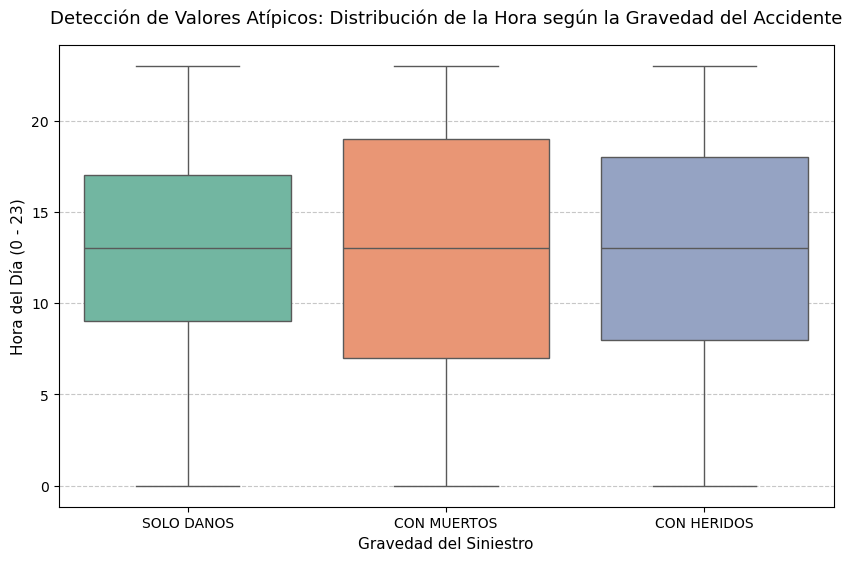

Gráfico 1 guardado exitosamente en: bloque1_eda/graficos/boxplot_horas_atipicos.png


In [32]:
plt.figure(figsize=(10, 6))

# Creamos el boxplot usando Seaborn
sns.boxplot(
    data=df_pandas_graficos, 
    x="GRAVEDAD", 
    y="HORA", 
    palette="Set2",
    fliersize=5  # Tamaño de los puntos atípicos si llegan a existir
)

# Estética profesional del gráfico
plt.title("Detección de Valores Atípicos: Distribución de la Hora según la Gravedad del Accidente", fontsize=13, pad=15)
plt.xlabel("Gravedad del Siniestro", fontsize=11)
plt.ylabel("Hora del Día (0 - 23)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar automáticamente en tu localhost dentro de la carpeta gráficos
plt.savefig("graficos/boxplot_horas_atipicos.png", bbox_inches='tight', dpi=300)
plt.show()
print("Gráfico 1 guardado exitosamente en: bloque1_eda/graficos/boxplot_horas_atipicos.png")

### Gráfico 2
Distribución de Accidentes por Hora y Franja Horaria

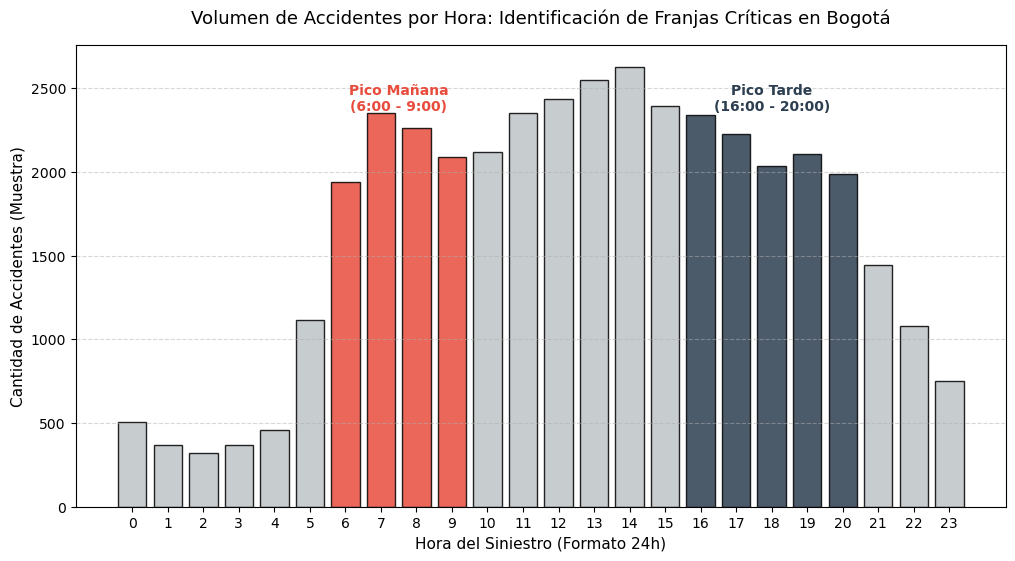

Gráfico 2 guardado exitosamente en: bloque1_eda/graficos/distribucion_horas_pico.png


In [33]:
plt.figure(figsize=(12, 6))

# Primero, creamos la lógica de colores para las franjas que definiste
# Mañana (6-9) -> Rojo/Naranja, Tarde (16-20) -> Azul/Oscuro, Valle -> Gris
colores_franjas = []
for hora in range(24):
    if 6 <= hora <= 9:
        colores_franjas.append('#e74c3c')  # Rojo - Pico Mañana
    elif 16 <= hora <= 20:
        colores_franjas.append('#2c3e50')  # Azul Oscuro - Pico Tarde
    else:
        colores_franjas.append('#bdc3c7')  # Gris - Hora Valle

# Contamos los accidentes por cada hora individual (0 a 23)
conteo_horas = df_pandas_graficos['HORA'].value_counts().sort_index()

# Dibujamos el gráfico de barras
plt.bar(
    conteo_horas.index, 
    conteo_horas.values, 
    color=colores_franjas, 
    edgecolor='black', 
    alpha=0.85
)

# Añadir etiquetas de texto para identificar las franjas en la gráfica
plt.text(7.5, max(conteo_horas.values)*0.9, "Pico Mañana\n(6:00 - 9:00)", color='#e74c3c', weight='bold', ha='center')
plt.text(18, max(conteo_horas.values)*0.9, "Pico Tarde\n(16:00 - 20:00)", color='#2c3e50', weight='bold', ha='center')

# Estética y títulos
plt.title("Volumen de Accidentes por Hora: Identificación de Franjas Críticas en Bogotá", fontsize=13, pad=15)
plt.xlabel("Hora del Siniestro (Formato 24h)", fontsize=11)
plt.ylabel("Cantidad de Accidentes (Muestra)", fontsize=11)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Guardar automáticamente en la carpeta de gráficos locales
plt.savefig("graficos/distribucion_horas_pico.png", bbox_inches='tight', dpi=300)
plt.show()
print("Gráfico 2 guardado exitosamente en: bloque1_eda/graficos/distribucion_horas_pico.png")

### Gráfico 3
Evolución de Accidentes por Mes y Línea de Tendencia Promedio

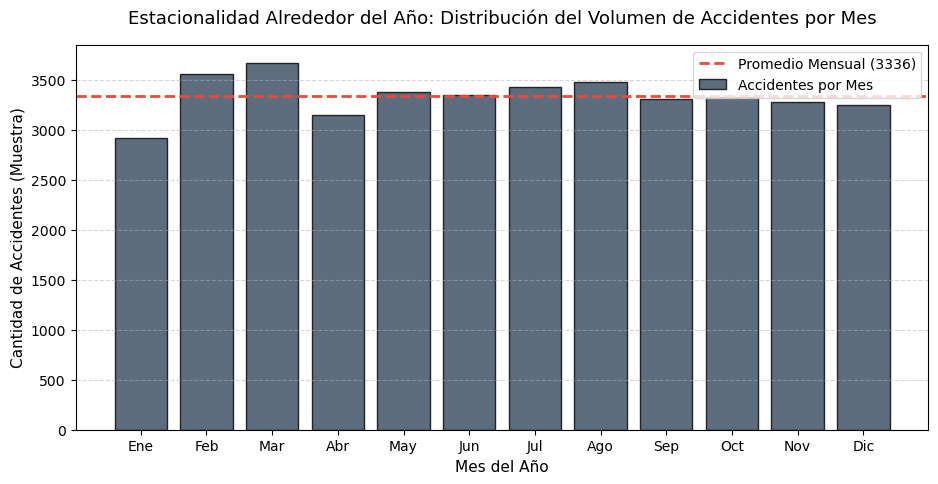

Gráfico 3 guardado exitosamente en: bloque1_eda/graficos/distribucion_mensual.png


In [34]:
plt.figure(figsize=(11, 5))

# Pasamos los datos del mes a Pandas usando nuestra muestra
df_pandas_mes = df.select("MES").sample(False, 0.2, seed=42).toPandas()

# Contamos los accidentes por cada mes (1 al 12)
conteo_meses = df_pandas_mes['MES'].value_counts().sort_index()

# Calculamos el promedio mensual de la muestra para usarlo como referencia estadística
promedio_mensual = conteo_meses.mean()

# Dibujamos las barras con un tono azul institucional
plt.bar(
    conteo_meses.index, 
    conteo_meses.values, 
    color='#34495e', 
    alpha=0.8, 
    edgecolor='black', 
    label='Accidentes por Mes'
)

# Trazamos la línea del promedio estadístico
plt.axhline(
    y=promedio_mensual, 
    color='#e74c3c', 
    linestyle='--', 
    linewidth=2, 
    label=f'Promedio Mensual ({int(promedio_mensual)})'
)

# Configuración de los nombres de los meses en el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.xticks(range(1, 13), nombres_meses)

# Estética y títulos profesionales
plt.title("Estacionalidad Alrededor del Año: Distribución del Volumen de Accidentes por Mes", fontsize=13, pad=15)
plt.xlabel("Mes del Año", fontsize=11)
plt.ylabel("Cantidad de Accidentes (Muestra)", fontsize=11)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Guardar automáticamente en tu localhost dentro de la subcarpeta gráficos
plt.savefig("graficos/distribucion_mensual.png", bbox_inches='tight', dpi=300)
plt.show()
print("Gráfico 3 guardado exitosamente en: bloque1_eda/graficos/distribucion_mensual.png")

### Gráfico 4
ranking de accidentalidad por localidad

/tmp/ipykernel_117559/3280984075.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


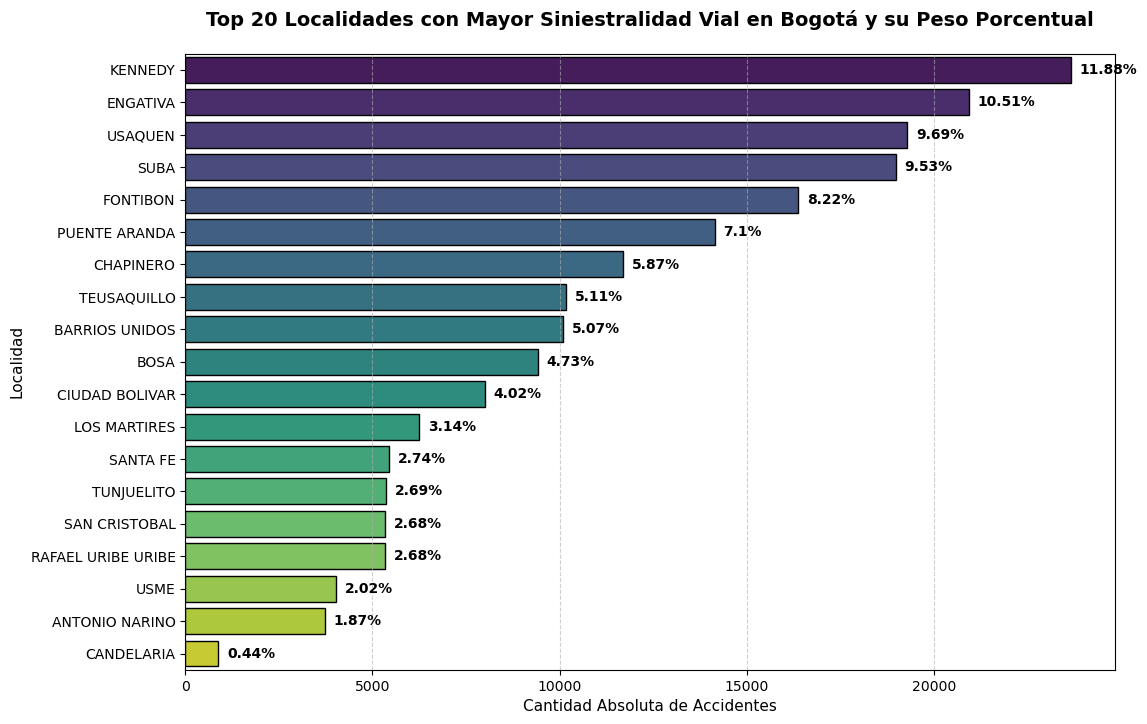

¡Gráfico de localidades guardado exitosamente en: bloque1_eda/graficos/ranking_localidades_porcentaje.png!


In [35]:
# ====================================================
# GRÁFICO 4: RANKING DE ACCIDENTALIDAD POR LOCALIDAD
# ====================================================

# 1. Convertir el resultado de Spark a Pandas (solo el Top 20 para que no quede muy saturado)
df_localidades_pd = df_localidades_porcentaje.limit(20).toPandas()

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(12, 8))

# 3. Crear el gráfico de barras horizontales (usamos 'y' para las localidades y 'x' para los accidentes)
ax = sns.barplot(
    data=df_localidades_pd,
    x="CONTEO_ACCIDENTES",
    y="LOCALIDAD",
    palette="viridis", # Una paleta de colores degradada y profesional
    edgecolor="black"
)

# 4. Agregar las etiquetas de porcentaje al final de cada barra de forma automática
for i, barra in enumerate(ax.patches):
    # Obtener el porcentaje correspondiente a esta localidad
    porcentaje = df_localidades_pd.loc[i, "PORCENTAJE"]
    # Calcular la posición del texto (un poco a la derecha del final de la barra)
    ancho_barra = barra.get_width()
    ax.text(
        ancho_barra + (max(df_localidades_pd["CONTEO_ACCIDENTES"]) * 0.01), # Posición X
        barra.get_y() + barra.get_height()/2,                             # Posición Y
        f'{porcentaje}%',                                                 # Texto
        va='center', 
        ha='left', 
        fontsize=10, 
        weight='bold'
    )

# 5. Estética, títulos y etiquetas del gráfico
plt.title("Top 20 Localidades con Mayor Siniestralidad Vial en Bogotá y su Peso Porcentual", fontsize=14, pad=20, weight='bold')
plt.xlabel("Cantidad Absoluta de Accidentes", fontsize=11)
plt.ylabel("Localidad", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 6. Guardar automáticamente en tu localhost dentro de la carpeta de gráficos
plt.savefig("graficos/ranking_localidades_porcentaje.png", bbox_inches='tight', dpi=300)
plt.show()

print("¡Gráfico de localidades guardado exitosamente en: bloque1_eda/graficos/ranking_localidades_porcentaje.png!")

In [36]:
df_accidentes_pico.show(5, truncate=True)

+--------+----------+----------------+------------------+---+---+----+--------------------+-----------+---------+--------------+----------+------------+--------+----------+----------------+
|OBJECTID|FORMULARIO|CODIGO_ACCIDENTE|ANO_OCURRENCIA_ACC|MES|DIA|HORA|           DIRECCION|   GRAVEDAD|CLASE_ACC|     LOCALIDAD|   LATITUD|    LONGITUD|     CIV|PK_CALZADA|  FRANJA_HORARIA|
+--------+----------+----------------+------------------+---+---+----+--------------------+-----------+---------+--------------+----------+------------+--------+----------+----------------+
|      10|A000240105|         4424883|              2015|  9| 26|  18|   KR 52A-CL 137A 35| SOLO DANOS|   CHOQUE|          SUBA|4.72462598|-74.05585328|11008301|     31431| HORA PICO TARDE|
|      13|A000551010|         4468708|              2016| 12| 27|  19|    CL 69A-KR 89A 02|CON HERIDOS|   CHOQUE|      ENGATIVA|4.69357846|-74.11058497|10006813|    219627| HORA PICO TARDE|
|      15|A000686495|         4495519|            

In [37]:

# 1. Exportamos desde Spark a una carpeta temporal unificando en 1 sola partición
ruta_temporal = "datos_limpios_temp"
df_picos.coalesce(1).write.csv(ruta_temporal, header=True, mode="overwrite")

try:
    # 2. Buscamos el archivo CSV real que generó Spark dentro de la carpeta
    archivo_spark = glob.glob(os.path.join(ruta_temporal, "part-*.csv"))[0]

    # 3. Lo movemos y renombramos en tu raíz del bloque 1 como 'datos_limpios.csv'
    # Usamos shutil.move que es más seguro entre sistemas de archivos
    shutil.move(archivo_spark, "datos_limpios.csv")
    print("¡Archivo 'datos_limpios.csv' creado correctamente!")

except IndexError:
    print("Error: No se encontró el archivo generado por Spark. Revisa si el DataFrame tiene datos.")

finally:
    # 4. Borramos la carpeta temporal de forma absoluta (incluyendo archivos ocultos y metadatos)
    if os.path.exists(ruta_temporal):
        shutil.rmtree(ruta_temporal)
        print("Carpeta temporal limpiada con éxito.")

print("\n¡Dataset optimizado guardado con éxito en: bloque1_eda/datos_limpios.csv!")

¡Archivo 'datos_limpios.csv' creado correctamente!
Carpeta temporal limpiada con éxito.

¡Dataset optimizado guardado con éxito en: bloque1_eda/datos_limpios.csv!


In [38]:
# Conteo de registros
total_filas = df_picos.count()
total_columnas = len(df_picos.columns)
print(f"Total de registros (filas): {total_filas:,}")
print(f"Total de variables (columnas): {total_columnas}")


Total de registros (filas): 199,146
Total de variables (columnas): 16


## Tarea 6 · Conclusiones

**Conclusion 1 — Calidad y estructura del dataset:**
El dataset de accidentalidad vial de Bogota D.C. contiene 199,146 registros sin duplicados y con nulos concentrados en tres variables: PK_CALZADA (19.07% nulos), CIV (0.85%) y LOCALIDAD (0.02% — 46 registros). Dado que PK_CALZADA es un identificador de calzada sin valor predictivo directo, sus nulos no comprometen el analisis. No se detectaron valores atipicos en HORA mediante IQR (límite superior teorico: 29, superior al rango real 0-23), lo que confirma la integridad temporal del dataset.

**Conclusion 2 — Patrones temporales de accidentalidad:**
La distribucion mensual muestra una accidentalidad relativamente estable a lo largo del año, con marzo (18,120 accidentes) y agosto (17,832) como los meses de mayor siniestralidad y enero (14,271) como el de menor volumen. La diferencia entre el mes mas y menos accidentado es del 27%, lo que sugiere que la accidentalidad en Bogotá no tiene una estacionalidad marcada sino un volumen sostenido durante todo el año. Por hora, las 14:00 (13,187) y 13:00 (12,544) concentran la mayor accidentalidad, coincidiendo con el mediodia laboral.

**Conclusion 3 — Gravedad y franja horaria:**
El analisis por franja horaria revela que la Hora Pico Mañana tiene la mayor proporcion de CON HERIDOS (37.20%) frente a Hora Valle (32.13%) y Hora Pico Tarde (35.07%), lo que sugiere mayor riesgo de lesiones en el trafico matutino. Los CHOQUES dominan en todas las franjas (83-87%), pero los ATROPELLOS son proporcionalmente mas frecuentes en Hora Pico Tarde (12.0%) que en Hora Pico Mañana (8.52%), lo que indica mayor riesgo para peatones en horas de la tarde. Kennedy (23,661 o 11.88%) y Engativa (20,928 o 10.51%) concentran el mayor volumen de accidentes por localidad.